# Healthcare Breach Portal — Exploratory Data Analysis

Data: HHS Office for Civil Rights (OCR) Breach Portal exports — breaches of unsecured protected
health information affecting **500 or more individuals** (the HIPAA reporting threshold).
Two files: `breach_active.csv` (cases under investigation) and `breach_archived.csv` (resolved cases).

**Known export defect:** the first column and the second-to-last column carry broken
`javax.faces.component.UIPanel@...` headers. Per the HHS field order these are
`Name of Covered Entity` and `Business Associate Present`; they are renamed on load.

**Known data limits** (kept in mind throughout):
- No financial/dollar-impact field exists. Any cost figures elsewhere in this project are estimates from an external cost-per-record benchmark, clearly labeled as such — never data-native.
- No rural/critical-access hospital flag exists. `Covered Entity Type` only has broad categories, so no rural-hospital claims are made from this data alone.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

## 1. Load, fix headers, concatenate

In [2]:
def load_breach_csv(path: str) -> pd.DataFrame:
    """Load an OCR breach portal export and repair the two broken headers."""
    df = pd.read_csv(path, dtype=str)
    cols = list(df.columns)
    cols[0] = "Name of Covered Entity"       # broken javax.faces header (1st col)
    cols[-2] = "Business Associate Present"  # broken javax.faces header (2nd-to-last col)
    df.columns = cols
    return df

active = load_breach_csv("../data/breach_active.csv").assign(Status="Under Investigation")
archived = load_breach_csv("../data/breach_archived.csv").assign(Status="Archived")
assert list(active.columns) == list(archived.columns)

df = pd.concat([active, archived], ignore_index=True)
print(f"active: {active.shape[0]:,} rows | archived: {archived.shape[0]:,} rows | combined: {df.shape[0]:,} rows")
df.head(3)

active: 733 rows | archived: 7,064 rows | combined: 7,797 rows


,Name of Covered Entity,State,Covered Entity Type,Individuals Affected,Breach Submission Date,Type of Breach,Location of Breached Information,Business Associate Present,Web Description,Status
0,Erlanger Health,TN,Healthcare Provider,4237,07/01/2026,Unauthorized Access/Disclosure,Electronic Medical Record,No,NaN,Under Investigation
1,Wisconsin Department of Health Services,WI,Health Plan,8157,07/01/2026,Unauthorized Access/Disclosure,Paper/Films,No,NaN,Under Investigation
2,Virta Health,CO,Business Associate,602,06/30/2026,Hacking/IT Incident,Network Server,Yes,NaN,Under Investigation


Note: the raw files have more physical lines than rows — `Web Description` values contain
embedded newlines inside quoted fields, which the CSV parser handles correctly.

## 2. Cleaning: dtypes, dates, duplicates, nulls

In [3]:
# Types
df["Individuals Affected"] = pd.to_numeric(df["Individuals Affected"], errors="coerce")
df["Breach Submission Date"] = pd.to_datetime(df["Breach Submission Date"], format="%m/%d/%Y")
df["Name of Covered Entity"] = df["Name of Covered Entity"].str.strip()

# Web Description contains embedded newlines and bare carriage returns (\r) that can
# trip CSV parsers on round-trip; normalize all whitespace runs to single spaces
df["Web Description"] = df["Web Description"].str.replace(r"\s+", " ", regex=True).str.strip()

# Exact duplicate reports (ignoring active/archived status flag)
dupes = df.duplicated(subset=[c for c in df.columns if c != "Status"]).sum()
df = df.drop_duplicates(subset=[c for c in df.columns if c != "Status"]).reset_index(drop=True)
print(f"dropped {dupes} exact duplicate rows -> {len(df):,} breaches")

# Derived fields
df["Year"] = df["Breach Submission Date"].dt.year
# Type of Breach can be comma-separated (e.g. "Loss, Theft"); keep the first as primary
df["Primary Breach Type"] = df["Type of Breach"].str.split(",").str[0].str.strip()

df.dtypes

dropped 2 exact duplicate rows -> 7,795 breaches


Name of Covered Entity                      object
State                                       object
Covered Entity Type                         object
Individuals Affected                       float64
Breach Submission Date              datetime64[ns]
Type of Breach                              object
Location of Breached Information            object
Business Associate Present                  object
Web Description                             object
Status                                      object
Year                                         int32
Primary Breach Type                         object
dtype: object

In [4]:
nulls = df.isna().sum().to_frame("nulls")
nulls["pct"] = (nulls["nulls"] / len(df) * 100).round(2)
print(f"Date range: {df['Breach Submission Date'].min():%Y-%m-%d} to {df['Breach Submission Date'].max():%Y-%m-%d}")
nulls[nulls.nulls > 0]

Date range: 2009-10-21 to 2026-07-01


,nulls,pct
State,24,0.31
Covered Entity Type,5,0.06
Individuals Affected,1,0.01
Type of Breach,1,0.01
Web Description,928,11.91
Primary Breach Type,1,0.01


Nulls are sparse: `Web Description` is empty for most active-portal rows (OCR only writes the
narrative at case resolution), plus a handful of missing states/entity types. Every record has a
name, date, and location; only one lacks `Individuals Affected`.

In [5]:
df["Individuals Affected"].describe().apply(lambda x: f"{x:,.0f}")

count          7,794
mean         133,252
std        2,521,006
min              500
25%            1,253
50%            3,916
75%           19,496
max      192,700,000
Name: Individuals Affected, dtype: object

The severity distribution is extremely heavy-tailed: median ~3.9k individuals per breach,
mean ~133k — pulled up by a few mega-breaches (max: 192.7M, Change Healthcare 2024).

## 3. Breaches by year

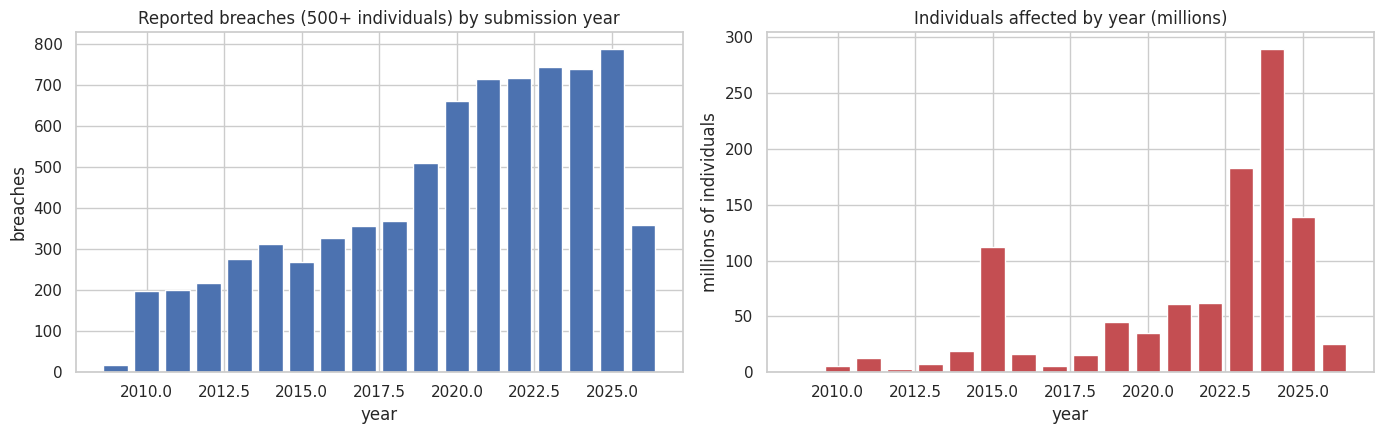

2026 is a partial year (data through July 1, 2026).


In [6]:
by_year = df.groupby("Year").agg(breaches=("Year", "size"),
                                 individuals=("Individuals Affected", "sum"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(by_year.index, by_year["breaches"], color="#4C72B0")
axes[0].set_title("Reported breaches (500+ individuals) by submission year")
axes[0].set_ylabel("breaches")
axes[1].bar(by_year.index, by_year["individuals"] / 1e6, color="#C44E52")
axes[1].set_title("Individuals affected by year (millions)")
axes[1].set_ylabel("millions of individuals")
for ax in axes:
    ax.set_xlabel("year")
plt.tight_layout()
plt.show()

print("2026 is a partial year (data through July 1, 2026).")

Breach *counts* more than doubled in a decade — from ~300/yr in the mid-2010s to ~700–790/yr in the 2020s (and ~3.7× the ~200/yr pace of the early 2010s).
Individuals affected is spikier: 2015 (Anthem, 78.8M) and 2024 (Change Healthcare, 192.7M) dominate.

## 4. Breaches by type

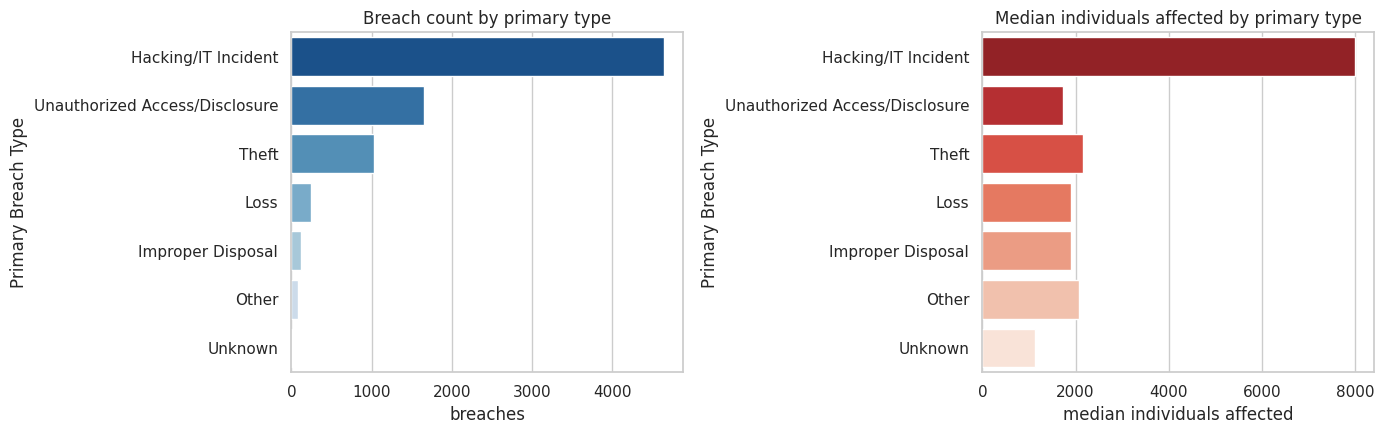

In [7]:
type_counts = df["Primary Breach Type"].value_counts()
type_median = df.groupby("Primary Breach Type")["Individuals Affected"].median().reindex(type_counts.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(x=type_counts.values, y=type_counts.index, hue=type_counts.index,
            ax=axes[0], palette="Blues_r", legend=False)
axes[0].set_title("Breach count by primary type")
axes[0].set_xlabel("breaches")
sns.barplot(x=type_median.values, y=type_median.index, hue=type_median.index,
            ax=axes[1], palette="Reds_r", legend=False)
axes[1].set_title("Median individuals affected by primary type")
axes[1].set_xlabel("median individuals affected")
plt.tight_layout()
plt.show()

Hacking/IT incidents are both the most common breach type **and** the most severe
(median 8,000 affected vs ~1,700–2,200 for every other type).

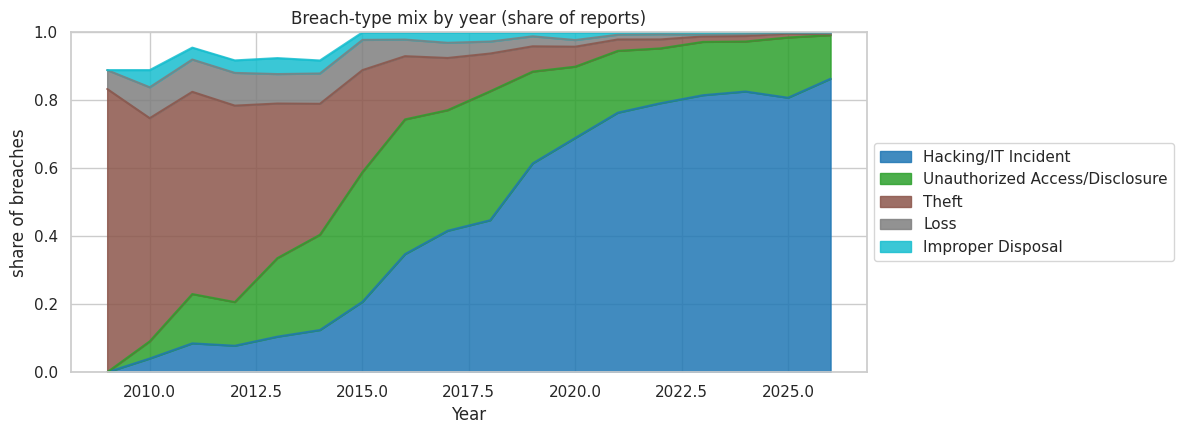

Hacking share: 2010 = 4%  ->  2024 = 83%
Theft share:   2010 = 66%  ->  2024 = 2%


In [8]:
# Composition shift over time
share = (df.groupby(["Year", "Primary Breach Type"]).size()
           .unstack(fill_value=0)
           .pipe(lambda t: t.div(t.sum(axis=1), axis=0)))
order = ["Hacking/IT Incident", "Unauthorized Access/Disclosure", "Theft", "Loss", "Improper Disposal"]
ax = share[order].plot(kind="area", stacked=True, figsize=(12, 4.5), colormap="tab10", alpha=0.85)
ax.set_title("Breach-type mix by year (share of reports)")
ax.set_ylabel("share of breaches")
ax.set_ylim(0, 1)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

print("Hacking share: 2010 = {:.0%}  ->  2024 = {:.0%}".format(share.loc[2010, "Hacking/IT Incident"],
                                                               share.loc[2024, "Hacking/IT Incident"]))
print("Theft share:   2010 = {:.0%}  ->  2024 = {:.0%}".format(share.loc[2010, "Theft"],
                                                               share.loc[2024, "Theft"]))

The dataset captures a full regime change: in 2010, half of reported breaches were physical
**theft** (stolen laptops, paper records) and only ~4% were hacking. By 2024, hacking is ~83% of
reports and theft has almost disappeared (~1–2%).

## 5. Breaches by covered entity type

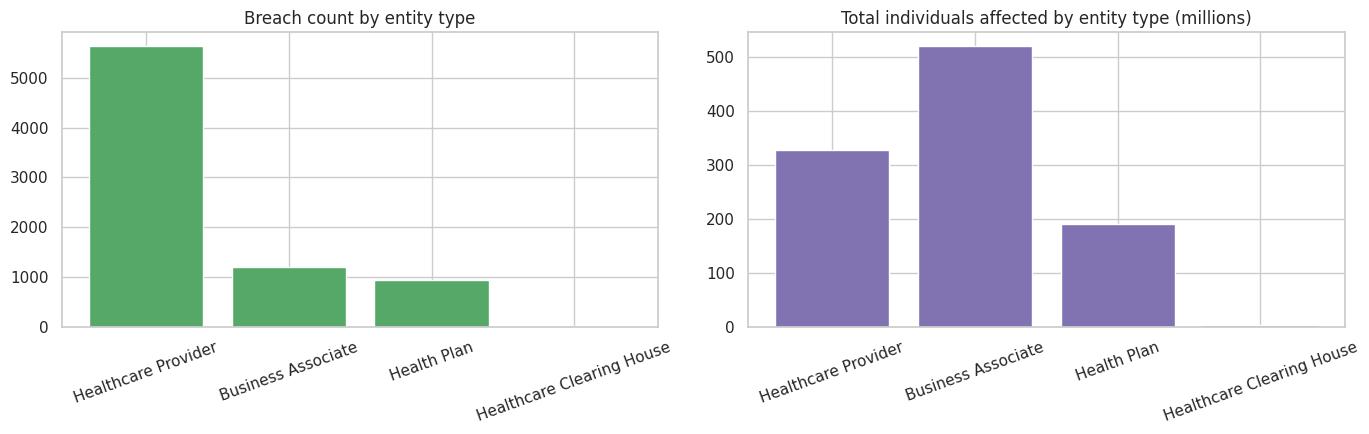

,breaches,total_affected,median_affected,share_of_reports,share_of_affected
Covered Entity Type,,,,,
Healthcare Provider,5633,327173546.0,3840.0,0.723,0.315
Business Associate,1196,519659895.0,5620.5,0.154,0.500
Health Plan,944,189430551.0,3000.0,0.121,0.182
Healthcare Clearing House,17,2262771.0,4204.0,0.002,0.002


In [9]:
ent = df.groupby("Covered Entity Type").agg(
    breaches=("Covered Entity Type", "size"),
    total_affected=("Individuals Affected", "sum"),
    median_affected=("Individuals Affected", "median")).sort_values("breaches", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(ent.index, ent["breaches"], color="#55A868")
axes[0].set_title("Breach count by entity type")
axes[1].bar(ent.index, ent["total_affected"] / 1e6, color="#8172B2")
axes[1].set_title("Total individuals affected by entity type (millions)")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

ent.assign(share_of_reports=(ent.breaches / ent.breaches.sum()).round(3),
           share_of_affected=(ent.total_affected / ent.total_affected.sum()).round(3))

**The most striking imbalance in the dataset:** Business Associates (vendors — claims
processors, IT providers, mailing houses) file only ~15% of breach reports but account for
**~50% of all individuals affected** (≈520M of ≈1.04B), and have the highest median breach size.
Third-party/vendor risk concentrates severity far above its share of incident counts.

## 6. Geography: top states

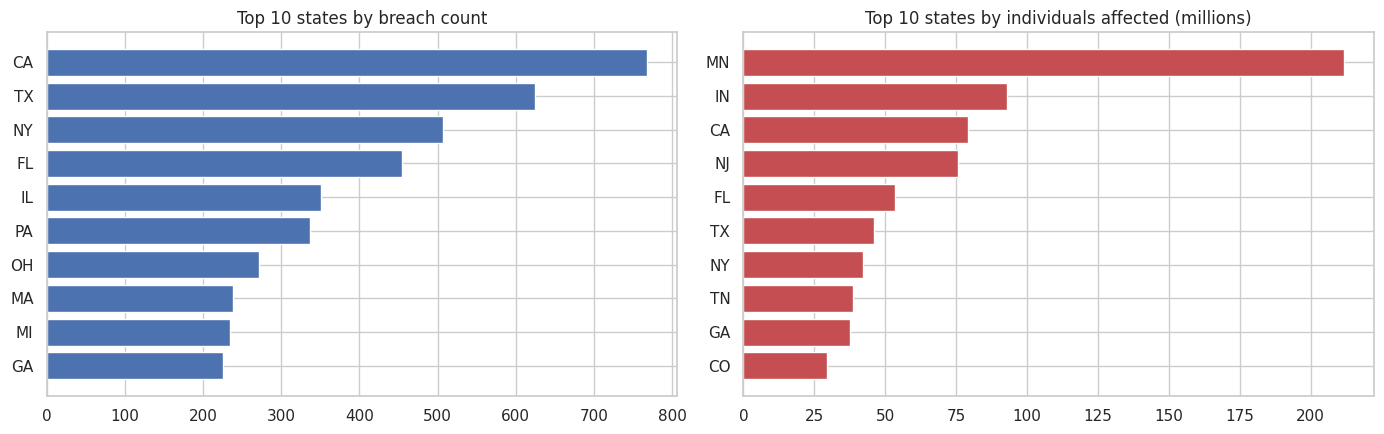

In [10]:
state = df.groupby("State").agg(breaches=("State", "size"),
                                total_affected=("Individuals Affected", "sum"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
top_ct = state.nlargest(10, "breaches")
axes[0].barh(top_ct.index[::-1], top_ct["breaches"][::-1], color="#4C72B0")
axes[0].set_title("Top 10 states by breach count")
top_af = state.nlargest(10, "total_affected")
axes[1].barh(top_af.index[::-1], top_af["total_affected"][::-1] / 1e6, color="#C44E52")
axes[1].set_title("Top 10 states by individuals affected (millions)")
plt.tight_layout()
plt.show()

Breach counts track population (CA, TX, NY, FL). Individuals affected does not: **MN leads
with ~212M**, almost entirely one event (Change Healthcare, 192.7M, headquartered in MN);
IN's 93M is mostly Anthem (78.8M, 2015). State totals are where a covered entity is registered,
not where affected patients live.

## 7. Severity distribution

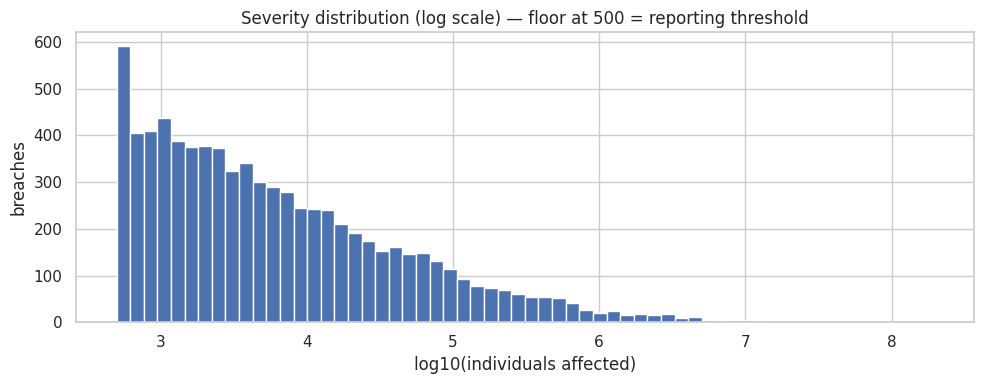

Top 5 breaches = 35% of all individuals affected


,Name of Covered Entity,State,Year,Individuals Affected,Type of Breach
720,"Change Healthcare, Inc.",MN,2024,192700000.0,Hacking/IT Incident
6541,Anthem Inc.,IN,2015,78800000.0,Hacking/IT Incident
334,Conduent Business Services LLC,NJ,2025,62224658.0,Hacking/IT Incident
2027,"Welltok, Inc.",CO,2023,14782887.0,Hacking/IT Incident
406,Aflac Incorporated (“Aflac”),GA,2025,13924906.0,Hacking/IT Incident


In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log10(df["Individuals Affected"].dropna()), bins=60, color="#4C72B0", edgecolor="white")
ax.set_xlabel("log10(individuals affected)")
ax.set_ylabel("breaches")
ax.set_title("Severity distribution (log scale) — floor at 500 = reporting threshold")
plt.tight_layout()
plt.show()

top5 = df.nlargest(5, "Individuals Affected")[
    ["Name of Covered Entity", "State", "Year", "Individuals Affected", "Type of Breach"]]
print(f"Top 5 breaches = {top5['Individuals Affected'].sum() / df['Individuals Affected'].sum():.0%} of all individuals affected")
top5

## 8. Save cleaned dataset

Cleaned data is reused by the clustering notebook and the Streamlit app.

In [12]:
df.to_csv("../data/breach_clean.csv", index=False)
print(f"saved ../data/breach_clean.csv  ({len(df):,} rows, {df.shape[1]} cols)")

saved ../data/breach_clean.csv  (7,795 rows, 12 cols)


## Findings summary (what the data actually shows)

1. **7,795 large breaches (Oct 2009 – Jul 2026) affecting ~1.04B individual records** (record-level, so one person breached twice counts twice; comparisons to the US population aren't one-to-one).
2. **Hacking replaced theft as the breach mechanism**: hacking went from ~4% of reports (2010) to ~83% (2024); physical theft collapsed from ~50% to ~1–2% over the same window.
3. **Hacking is also the most severe type**: median 8,000 individuals per incident vs ~1,700–2,200 for all other types.
4. **Vendor concentration**: Business Associates file ~15% of reports but account for ~50% of all affected individuals.
5. **Heavy tail**: the top 5 breaches (led by Change Healthcare 2024, 192.7M) account for roughly a third of all individuals ever affected; the median breach is under 4,000.
6. **Geography reflects HQ location, not exposure**: MN "leads" only because Change Healthcare is registered there.

*(No financial or rural-hospital conclusions are drawn — those fields don't exist in this data.)*